# 농산물 가격 예측 프로젝트

2018~2021년 국내 주요 농산물 10종의 가격 데이터를 바탕으로, **향후 가격을 예측**하는 모델을 개발한다.

**데이터 구조**

| 파일 | 설명 |
|---|---|
| `train.csv` | 품목별 시점(상·중·하순)당 평균가격. 행마다 품종명·거래단위·등급이 다름 |
| `산지공판장` 메타 | 시점·품목·공판장별 총반입량, 평균가, 경매건수 (수급 지표) |
| `전국도매` 메타 | 시점·품목·도매시장별 총반입량, 평균가, 경매건수 (수급 지표) |
| `test` 파일 | 예측 대상 시점 정보 (25개 파일) |

**분석 흐름**
1. 기본 세팅 → 2. 전처리 → 3. EDA → 4. 피처 엔지니어링 → 5. 모델링

---

## 1. 기본 세팅
한글 폰트를 먼저 설정해야 이후 시각화에서 한글이 깨지지 않는다.  
이후 라이브러리를 import하고 train 데이터를 로드한다.

In [23]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = r"C:\Dev\fonts\NanumGothic-Regular.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(style="whitegrid", rc={"font.family": font_name, "axes.unicode_minus": False})
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용된 폰트:", font_name)

적용된 폰트: NanumGothic


In [24]:
import warnings; warnings.filterwarnings("ignore")
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_raw = pd.read_csv("./Data/train/train.csv")

print(f"train        : {train_raw.shape}")
print(f"test  files  : {len(glob.glob('./Data/test/TEST_*.csv'))}")
print(f"train meta   : {len(glob.glob('./Data/train/meta/*.csv'))}")
print(f"test  meta   : {len(glob.glob('./Data/test/meta/*.csv'))}")
display(train_raw.head(3))

train        : (29376, 7)
test  files  : 25
train meta   : 4
test  meta   : 50


,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,201801상순,건고추,화건,30 kg,상품,381666.666667,590000.0
1,201801중순,건고추,화건,30 kg,상품,380809.666667,590000.0
2,201801하순,건고추,화건,30 kg,상품,380000.000000,590000.0


## 2. 전처리

### 2-1. 결측치 처리

`train.csv`에는 가격이 `0`으로 기록된 행이 다수 존재한다.  
이는 해당 시점에 실제 거래가 없었거나 데이터가 수집되지 않은 경우로, 실제 가격이 0원인 것이 아니다.  
따라서 0을 결측치로 간주하고 아래 방식으로 처리한다.

- `0` → `NaN` 변환 후 **스플라인 보간 (3차, order=3)** (시계열 연속성 + 곡선 추세 유지)
- 양 끝단의 NaN은 `ffill` / `bfill` 로 보완
- **품목별로 독립 처리** — 한 번에 처리하면 서로 다른 품목의 가격 구간이 보간에 섞임

> **선형 vs 스플라인 보간**: 선형 보간은 두 점을 직선으로 연결해 꺾임이 생기지만,  
> 3차 스플라인은 인접 구간의 기울기까지 연속으로 맞춰 **부드러운 곡선**으로 복원한다.  
> 농산물 가격처럼 완만하게 변하는 데이터에 더 자연스러운 보간이 가능하다.

먼저 품목별 0값 비율을 확인해 결측치 처리의 필요성을 파악한다.  
비율이 높을수록 보간이 가격 흐름에 미치는 영향이 크므로 주의가 필요하다.

In [25]:
품목_리스트 = train_raw["품목명"].unique()

# 품목별 0값(결측 의심) 현황
zero_stats = (train_raw.groupby("품목명")["평균가격(원)"]
              .agg(전체="count", 영값=lambda x: (x == 0).sum())
              .assign(비율=lambda x: (x["영값"] / x["전체"] * 100).round(1).astype(str) + "%"))
print(zero_stats.to_string())

           전체    영값     비율
품목명                       
감자       4752  2814  59.2%
건고추      1152   554  48.1%
깐마늘(국산)   288     0   0.0%
대파       3024   951  31.4%
무        4752  3055  64.3%
배         576   262  45.5%
배추       3744   490  13.1%
사과        720   399  55.4%
상추        576     0   0.0%
양파       9792  4188  42.8%


In [26]:
processed_dfs = []

for name in 품목_리스트:
    target_df = train_raw[train_raw["품목명"] == name].copy()
    s = target_df["평균가격(원)"].replace(0, np.nan)
    s = s.interpolate(method="spline", order=3)
    s = s.replace([np.inf, -np.inf], np.nan)  # 스플라인이 만든 inf 처리
    s = s.clip(lower=0)                        # 음수 → 0
    s = s.replace(0, np.nan)                   # clip으로 생긴 0도 결측 처리
    s = s.ffill().bfill()
    target_df["평균가격(원)"] = s
    processed_dfs.append(target_df)

train = pd.concat(processed_dfs).reset_index(drop=True)
neg = (train['평균가격(원)'] < 0).sum()
inf_cnt = np.isinf(train['평균가격(원)']).sum()
print(f"NaN: {train['평균가격(원)'].isna().sum()}  0값: {(train['평균가격(원)'] == 0).sum()}  음수: {neg}  inf: {inf_cnt}")

NaN: 0  0값: 0  음수: 0  inf: 0


### 2-2. 메타데이터 병합

`train.csv`는 가격 정보만 담고 있다. 가격에 영향을 주는 **공급량(수급 지표)**을 추가하기 위해 메타 파일을 병합한다.

**메타 파일 구성**

| 파일 | 주요 컬럼 | 특징 |
|---|---|---|
| `산지공판장` | 총반입량, 평균가(원/kg), 경매건수 | 공판장·품종·등급별로 행이 나뉨 |
| `전국도매` | 총반입량, 평균가(원/kg), 경매건수 | 도매시장·품종별로 행이 나뉨 |

메타 파일은 같은 시점·품목에 여러 행이 존재하므로, `시점 + 품목명` 기준으로 집계(반입량 합산, 가격 평균)해 **1:1 Left Join**이 가능하도록 만든다.

**예외 처리**
- `깐마늘(국산)`: train의 품목명이 메타에서는 `마늘`로 등록 → 매핑 딕셔너리로 처리
- `건고추`: 메타 파일에 아예 없음 → join 후 수급 컬럼이 NaN (이후 0으로 대체)

In [27]:
산지공판장 = pd.read_csv("./Data/train/meta/TRAIN_산지공판장_2018-2021.csv", encoding="utf-8-sig")
전국도매   = pd.read_csv("./Data/train/meta/TRAIN_전국도매_2018-2021.csv",   encoding="utf-8-sig")

print(f"산지공판장 {산지공판장.shape} | 품목: {sorted(산지공판장['품목명'].unique())}")
print(f"전국도매   {전국도매.shape}   | 품목: {sorted(전국도매['품목명'].unique())}")

산지공판장 (118628, 21) | 품목: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']
전국도매   (176014, 22)   | 품목: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']


In [28]:
# 깐마늘(국산)은 메타에서 "마늘"로 등록됨
품목명_매핑 = {"깐마늘(국산)": "마늘"}

gj_agg = (산지공판장
          .groupby(["시점", "품목명"], as_index=False)
          .agg(
              공판장_총반입량 = ("총반입량(kg)",  "sum"),
              공판장_평균가   = ("평균가(원/kg)", "mean"),
              공판장_경매건수 = ("경매 건수",     "sum"),
          ))

dm_agg = (전국도매
          .groupby(["시점", "품목명"], as_index=False)
          .agg(
              도매_총반입량 = ("총반입량(kg)",  "sum"),
              도매_평균가   = ("평균가(원/kg)", "mean"),
              도매_경매건수 = ("경매 건수",     "sum"),
          ))

train_m = train.copy()
train_m["_meta_품목명"] = train_m["품목명"].replace(품목명_매핑)

train_merged = (train_m
                .merge(gj_agg.rename(columns={"품목명": "_meta_품목명"}),
                       on=["시점", "_meta_품목명"], how="left")
                .merge(dm_agg.rename(columns={"품목명": "_meta_품목명"}),
                       on=["시점", "_meta_품목명"], how="left")
                .drop(columns="_meta_품목명")
                .reset_index(drop=True))

print(f"shape: {train_merged.shape}")
print(train_merged.groupby("품목명")["공판장_평균가"]
      .apply(lambda x: f"{x.isna().mean()*100:.0f}%").to_string())


shape: (29376, 13)
품목명
감자           0%
건고추        100%
깐마늘(국산)      0%
대파           0%
무            0%
배            0%
배추           0%
사과           0%
상추           0%
양파           0%


### 2-3. 피처 엔지니어링 기반 전처리

EDA 및 모델링에 공통으로 필요한 피처를 한 번에 생성한다.

| 피처 | 설명 |
|---|---|
| `year`, `month`, `순`, `t_idx` | `시점` 문자열 → 수치 파싱. `t_idx` 기준으로 시계열 정렬 |
| `total_반입량` | 공판장 + 도매 반입량 합산 (수급 지표) |
| `lag1` ~ `lag9` | 과거 N시점 가격. EDA 4 상관분석 및 시계열 피처로 활용 |
| `target_ma_3/6/9` | 직전 N순 rolling 평균가. 단기 추세 노이즈 완화 |
| `sin/cos_month`, `sin/cos_순` | 계절성 원형 인코딩 (1월↔12월 연속 표현) |
| `event`, `is_event` | 설날·추석·김장 이벤트 라벨 |

> `lag`·`rolling`은 모두 `shift(1)` 기반 → **data leakage 없음**

In [29]:
df = train_merged.copy()

# "201801상순" → year=2018, month=1, 순=1
# t_idx: 품목별 lag/rolling 계산을 위한 정렬 기준
순_map = {'상순': 1, '중순': 2, '하순': 3}
df['year']  = df['시점'].str[:4].astype(int)
df['month'] = df['시점'].str[4:6].astype(int)
df['순']    = df['시점'].str[6:].map(순_map)
df['t_idx'] = (df['year'] - 2018) * 36 + (df['month'] - 1) * 3 + (df['순'] - 1)

df = df.sort_values(['품목명', 't_idx']).reset_index(drop=True)
print(df[['시점', 'year', 'month', '순', 't_idx']].drop_duplicates().head(6).to_string(index=False))

      시점  year  month  순  t_idx
201801상순  2018      1  1      0
201801중순  2018      1  2      1
201801하순  2018      1  3      2
201802상순  2018      2  1      3
201802중순  2018      2  2      4
201802하순  2018      2  3      5


In [30]:
# 건고추는 메타에 없어 NaN → 0으로 처리 후 합산
df['total_반입량'] = df['공판장_총반입량'].fillna(0) + df['도매_총반입량'].fillna(0)

print(df.groupby('품목명')['total_반입량'].sum().sort_values(ascending=False).to_string())

품목명
양파         3.338008e+11
무          1.239917e+11
배추         8.086004e+10
감자         5.804960e+10
대파         3.534168e+10
사과         1.267349e+10
배          3.624613e+09
상추         2.062705e+09
깐마늘(국산)    1.430863e+09
건고추        0.000000e+00


In [31]:
for lag in range(1, 10):
    df[f'lag{lag}'] = df.groupby('품목명')['평균가격(원)'].shift(lag)

display(df[['품목명', '시점', '평균가격(원)', 'lag1', 'lag2', 'lag3']].head(5))

,품목명,시점,평균가격(원),lag1,lag2,lag3
0,감자,201801상순,44170.285714,NaN,NaN,NaN
1,감자,201801상순,54983.498834,44170.285714,NaN,NaN
2,감자,201801상순,16115.285714,54983.498834,44170.285714,NaN
3,감자,201801상순,18928.318402,16115.285714,54983.498834,44170.285714
4,감자,201801상순,97766.108809,18928.318402,16115.285714,54983.498834


In [32]:
# shift(1) 기반이므로 data leakage 없음
for w in [3, 6, 9]:
    df[f'target_ma_{w}'] = (
        df.groupby('품목명')['평균가격(원)']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )

display(df[['품목명', '시점', '평균가격(원)', 'target_ma_3', 'target_ma_6', 'target_ma_9']].head(5))

,품목명,시점,평균가격(원),target_ma_3,target_ma_6,target_ma_9
0,감자,201801상순,44170.285714,NaN,NaN,NaN
1,감자,201801상순,54983.498834,44170.285714,44170.285714,44170.285714
2,감자,201801상순,16115.285714,49576.892274,49576.892274,49576.892274
3,감자,201801상순,18928.318402,38423.023421,38423.023421,38423.023421
4,감자,201801상순,97766.108809,30009.034317,33549.347166,33549.347166


In [33]:
# 1월과 12월이 연속으로 이어지도록 원형 인코딩
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
df['sin_순']    = np.sin(2 * np.pi * df['순'] / 3)
df['cos_순']    = np.cos(2 * np.pi * df['순'] / 3)

print(df[['month', '순', 'sin_month', 'cos_month']].drop_duplicates().sort_values(['month', '순']).head(9).to_string(index=False))

 month  순  sin_month    cos_month
     1  1   0.500000 8.660254e-01
     1  2   0.500000 8.660254e-01
     1  3   0.500000 8.660254e-01
     2  1   0.866025 5.000000e-01
     2  2   0.866025 5.000000e-01
     2  3   0.866025 5.000000e-01
     3  1   1.000000 6.123234e-17
     3  2   1.000000 6.123234e-17
     3  3   1.000000 6.123234e-17


In [34]:
# 설날: 1월 하순~2월 중순 / 추석: 9월 중순~10월 상순 / 김장: 11월
m, s = df['month'], df['순']
df['event'] = np.select(
    condlist=[
        ((m == 1) & (s == 3)) | ((m == 2) & (s.isin([1, 2]))),
        ((m == 9) & (s.isin([2, 3]))) | ((m == 10) & (s == 1)),
        m == 11,
    ],
    choicelist=['설날', '추석', '김장'],
    default='없음'
)
df['is_event'] = (df['event'] != '없음').astype(int)

print(df['event'].value_counts().to_string())
print(f"\nfinal shape: {df.shape}")

event
없음    22032
설날     2448
추석     2448
김장     2448

final shape: (29376, 36)


In [35]:
# 이벤트별 윈도우 정의 (t_idx 연도 내 상대값 기준)
# window: 이벤트 기간 / pre: 전 2순 / post: 후 2순
event_windows = {
    '설날': {'window': [2, 3, 4],    'pre': [0, 1],    'post': [5, 6]},
    '추석': {'window': [25, 26, 27], 'pre': [23, 24],  'post': [28, 29]},
    '김장': {'window': [30, 31, 32], 'pre': [28, 29],  'post': [33, 34]},
}

df['event_impact'] = np.nan

for 품목 in df['품목명'].unique():
    for year in df['year'].unique():
        year_offset = (year - 2018) * 36
        item_mask   = (df['품목명'] == 품목) & (df['year'] == year)

        # 해당 품목·연도의 t_idx → 평균가격 매핑
        price_by_tidx = df[item_mask].groupby('t_idx')['평균가격(원)'].mean()

        for event_name, w in event_windows.items():
            pre_idx  = [year_offset + i for i in w['pre']]
            post_idx = [year_offset + i for i in w['post']]
            win_idx  = [year_offset + i for i in w['window']]

            pre_mean  = price_by_tidx.reindex(pre_idx).mean()
            post_mean = price_by_tidx.reindex(post_idx).mean()

            if pd.notna(pre_mean) and pre_mean != 0 and pd.notna(post_mean):
                impact = post_mean / pre_mean - 1   # 양수: 이후 가격 상승, 음수: 하락
                df.loc[item_mask & df['t_idx'].isin(win_idx), 'event_impact'] = impact

# 이벤트 없는 기간은 0으로 채움
df['event_impact'] = df['event_impact'].fillna(0)

print(df.groupby('event')['event_impact'].mean().round(3).to_string())
print(f"\nfinal shape: {df.shape}")

event
김장    0.022
설날   -0.005
없음    0.000
추석    0.042

final shape: (29376, 37)


## 3. EDA

### 3-1. 품목별 가격 추이와 분포

- 선 그래프: 전체 기간(2018~2021) 가격 흐름 → 계절성·급등락 패턴 확인
- 박스 플롯: 가격 분포와 이상치 확인

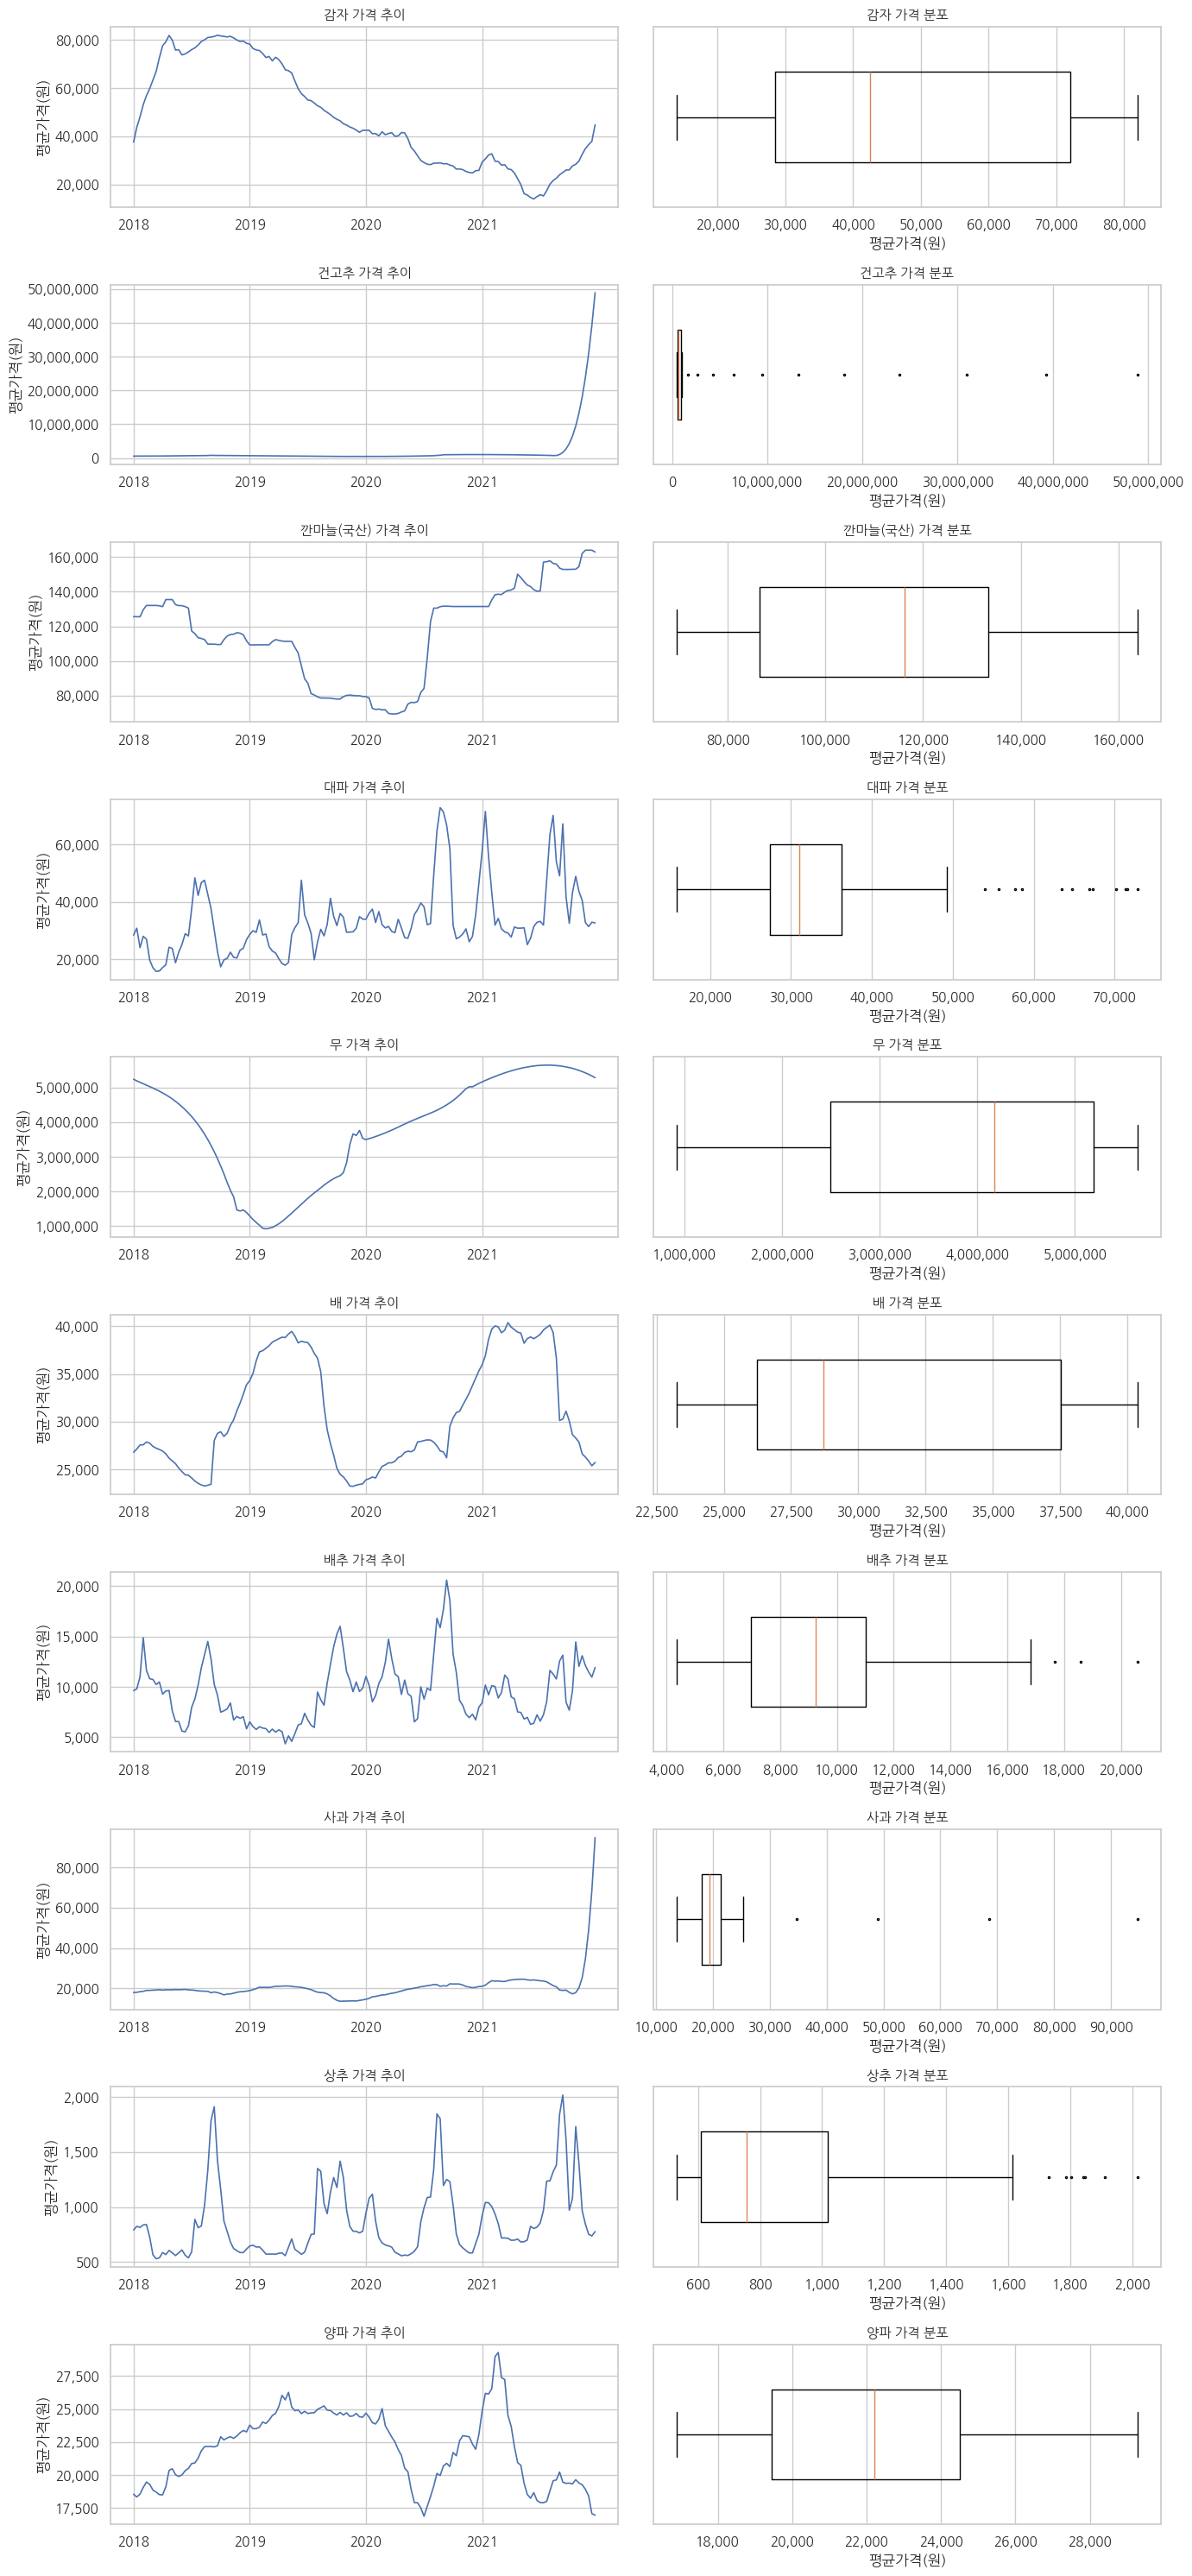

In [36]:
import matplotlib.ticker as ticker

품목_목록 = sorted(df['품목명'].unique())
comma_fmt = ticker.FuncFormatter(lambda x, _: f'{int(x):,}')

# 같은 시점에 품종/등급별 여러 행이 있으므로 시점별 평균으로 집계
df_plot = df.groupby(['품목명', 't_idx'], as_index=False)['평균가격(원)'].mean()

# x축 tick: 매년 1월 상순 (t_idx 0, 36, 72, 108)
year_ticks  = [0, 36, 72, 108]
year_labels = ['2018', '2019', '2020', '2021']

fig, axes = plt.subplots(len(품목_목록), 2, figsize=(14, len(품목_목록) * 3))

for i, 품목 in enumerate(품목_목록):
    item_df = df_plot[df_plot['품목명'] == 품목].sort_values('t_idx')
    prices  = item_df['평균가격(원)'].dropna()

    # 가격 추이
    axes[i, 0].plot(item_df['t_idx'], prices, linewidth=1.2)
    axes[i, 0].set_title(f'{품목} 가격 추이', fontsize=11)
    axes[i, 0].set_ylabel('평균가격(원)')
    axes[i, 0].set_xticks(year_ticks)
    axes[i, 0].set_xticklabels(year_labels)
    axes[i, 0].yaxis.set_major_formatter(comma_fmt)

    # 가격 분포
    axes[i, 1].boxplot(prices, vert=False, widths=0.5,
                       flierprops=dict(marker='.', markersize=3))
    axes[i, 1].set_title(f'{품목} 가격 분포', fontsize=11)
    axes[i, 1].set_xlabel('평균가격(원)')
    axes[i, 1].set_yticks([])
    axes[i, 1].xaxis.set_major_formatter(comma_fmt)

plt.tight_layout()
plt.show()

### 3-2. 품목별 가격 변동성 (CV)

**변동계수(CV = 표준편차 / 평균)** 로 품목별 가격 불안정성을 비교한다.

CV가 클수록 가격이 날씨·병해충 등 외부 요인에 민감하게 반응한다는 의미이며, 변동성이 높은 품목일수록 lag 피처 외에 추가적인 설명 변수가 더 중요해진다.

**CV 계산 기준 선택**

원본 데이터(`train_raw`)에는 실제 미거래 또는 수집 누락으로 인해 0값이 다수 포함되어 있다.  
0을 그대로 포함해 CV를 계산하면 평균이 인위적으로 낮아져 CV가 과장된다.  
예를 들어 `무`는 전체 데이터의 **64.3%가 0**이어서 raw 기준 CV가 5.9로 크게 튄다.

| 계산 기준 | 특징 |
|---|---|
| raw 데이터 (0 포함) | 결측 비율이 높은 품목의 CV가 왜곡됨 |
| 보간 후 데이터 (0 제거) | 실제 가격 흐름만 반영한 순수 변동성 |

따라서 **보간 완료 후 시점별 평균 집계(`df_plot`)** 를 기준으로 CV를 산출한다.

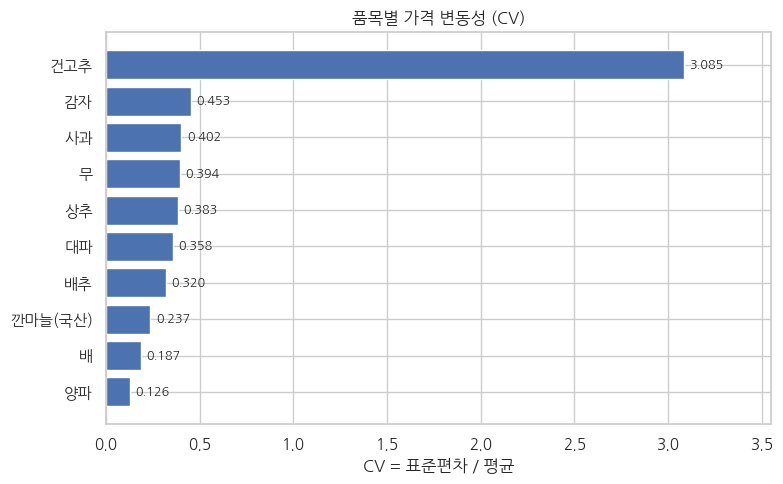

In [37]:
# 보간 완료된 df 기준, 시점별 평균 집계 후 CV 계산
cv = (df_plot.groupby('품목명')['평균가격(원)']
      .agg(lambda x: x.std() / x.mean())
      .sort_values(ascending=True)
      .rename('CV'))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(cv.index, cv.values)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlabel('CV = 표준편차 / 평균')
ax.set_title('품목별 가격 변동성 (CV)')
ax.set_xlim(0, cv.max() * 1.15)

plt.tight_layout()
plt.show()

### 3-3. 품목별 계절성 확인

연도별 변동을 제거하고 **월별 평균가격**만 보면 품목 고유의 계절 패턴이 드러난다.  
같은 품목이라도 연도마다 절대 가격이 다르기 때문에, 여러 해의 데이터를 월 기준으로 평균 내어 패턴을 확인한다.

| 유형 | 품목 | 특징 |
|---|---|---|
| 봄 최대 | 감자 | 봄철 가격 상승 |
| 여름 최대 | 배, 사과 | 여름철 가격 상승 |
| 가을 최대 | 배추, 무, 상추, 건고추 | 9월 중심 가격 급등 |
| 계절성 약함 | 깐마늘 | 뚜렷한 계절성 없음 |
| 기타 복잡한 모양 | 대파, 양파 | 대파: 2·9월 최대 / 6월 최저, 양파: 초반 고가 → 중반 저가 → 회복 |

이 계절 패턴은 이후 `sin/cos_month` 원형 인코딩 피처와 이벤트 라벨(`설날`, `추석`, `김장`)의 설계 근거가 된다.

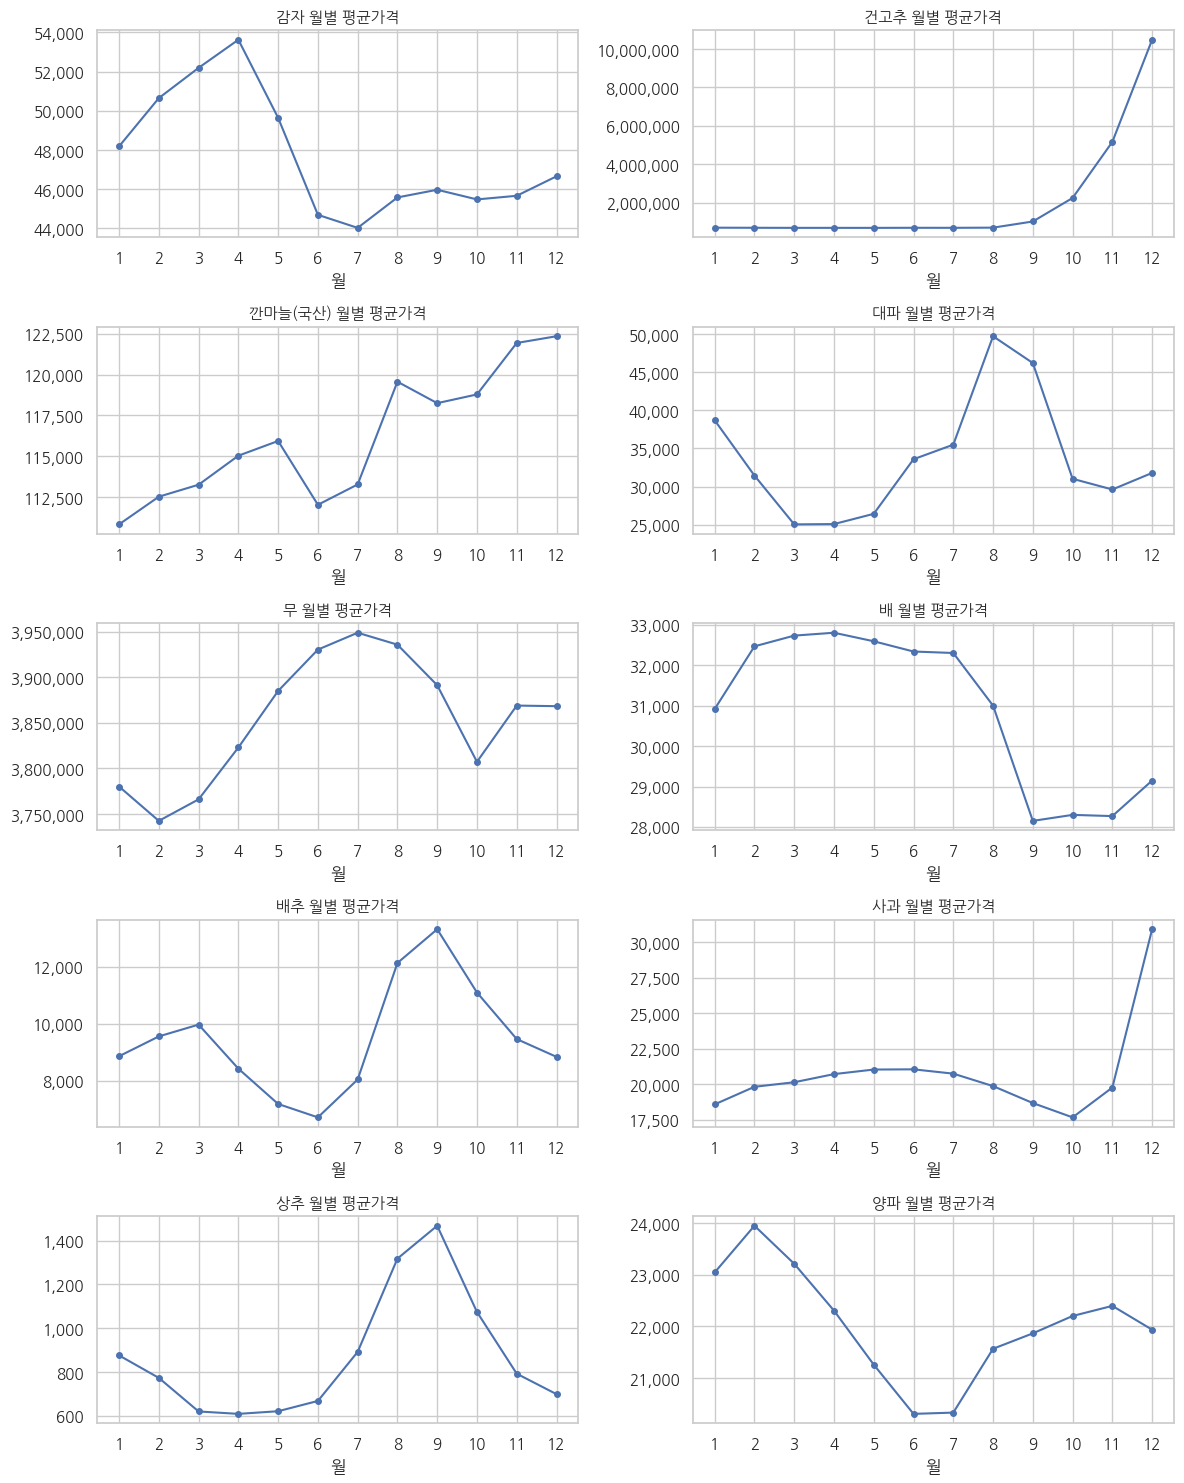

In [38]:
import matplotlib.ticker as ticker

comma_fmt = ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
품목_목록 = sorted(df['품목명'].unique())

# 연도 평균 제거 후 월별 패턴만 추출
df_season = df.groupby(['품목명', 'month'], as_index=False)['평균가격(원)'].mean()

fig, axes = plt.subplots(5, 2, figsize=(12, 15))
axes = axes.flatten()

for i, 품목 in enumerate(품목_목록):
    item_df = df_season[df_season['품목명'] == 품목].sort_values('month')
    axes[i].plot(item_df['month'], item_df['평균가격(원)'], marker='o', linewidth=1.5, markersize=4)
    axes[i].set_title(f'{품목} 월별 평균가격', fontsize=11)
    axes[i].set_xlabel('월')
    axes[i].set_xticks(range(1, 13))
    axes[i].yaxis.set_major_formatter(comma_fmt)

plt.tight_layout()
plt.show()

### 3-4. 직전 시점 가격과 현재 가격의 관계

`lag1`(직전 순의 가격)과 현재 가격의 산점도를 그려 **가격 관성**의 크기를 품목별로 비교한다.  
점이 대각선(y = x) 근처에 촘촘히 모일수록 "직전 가격이 현재 가격을 잘 예측한다"는 의미다.

**관찰 결과**

모든 품목에서 lag1과 현재 가격 사이에 **양의 상관관계**가 확인되었다.  
다만 상관의 강도는 품목마다 뚜렷하게 차이가 난다.

| 수준 | 품목 | 관찰 내용 |
|---|---|---|
| 고상관 | 깐마늘, 건고추, 배, 사과, 양파 | 점이 대각선에 밀집 — lag1만으로 설명력 충분 |
| 중간 | 감자, 대파 | 전반적 추세는 잡히지만 분산이 존재 |
| 저상관 | 무, 배추, 상추 | 급등·급락 구간에서 대각선을 크게 벗어남 |

저상관 품목은 계절적 이벤트(추석·김장)나 기상 요인에 의해 가격이 급변하는 경우가 많아  
lag1 하나로는 설명이 부족하다. 수급량(`total_반입량`), 이벤트 라벨, rolling 평균 등 추가 피처가 필요하다.

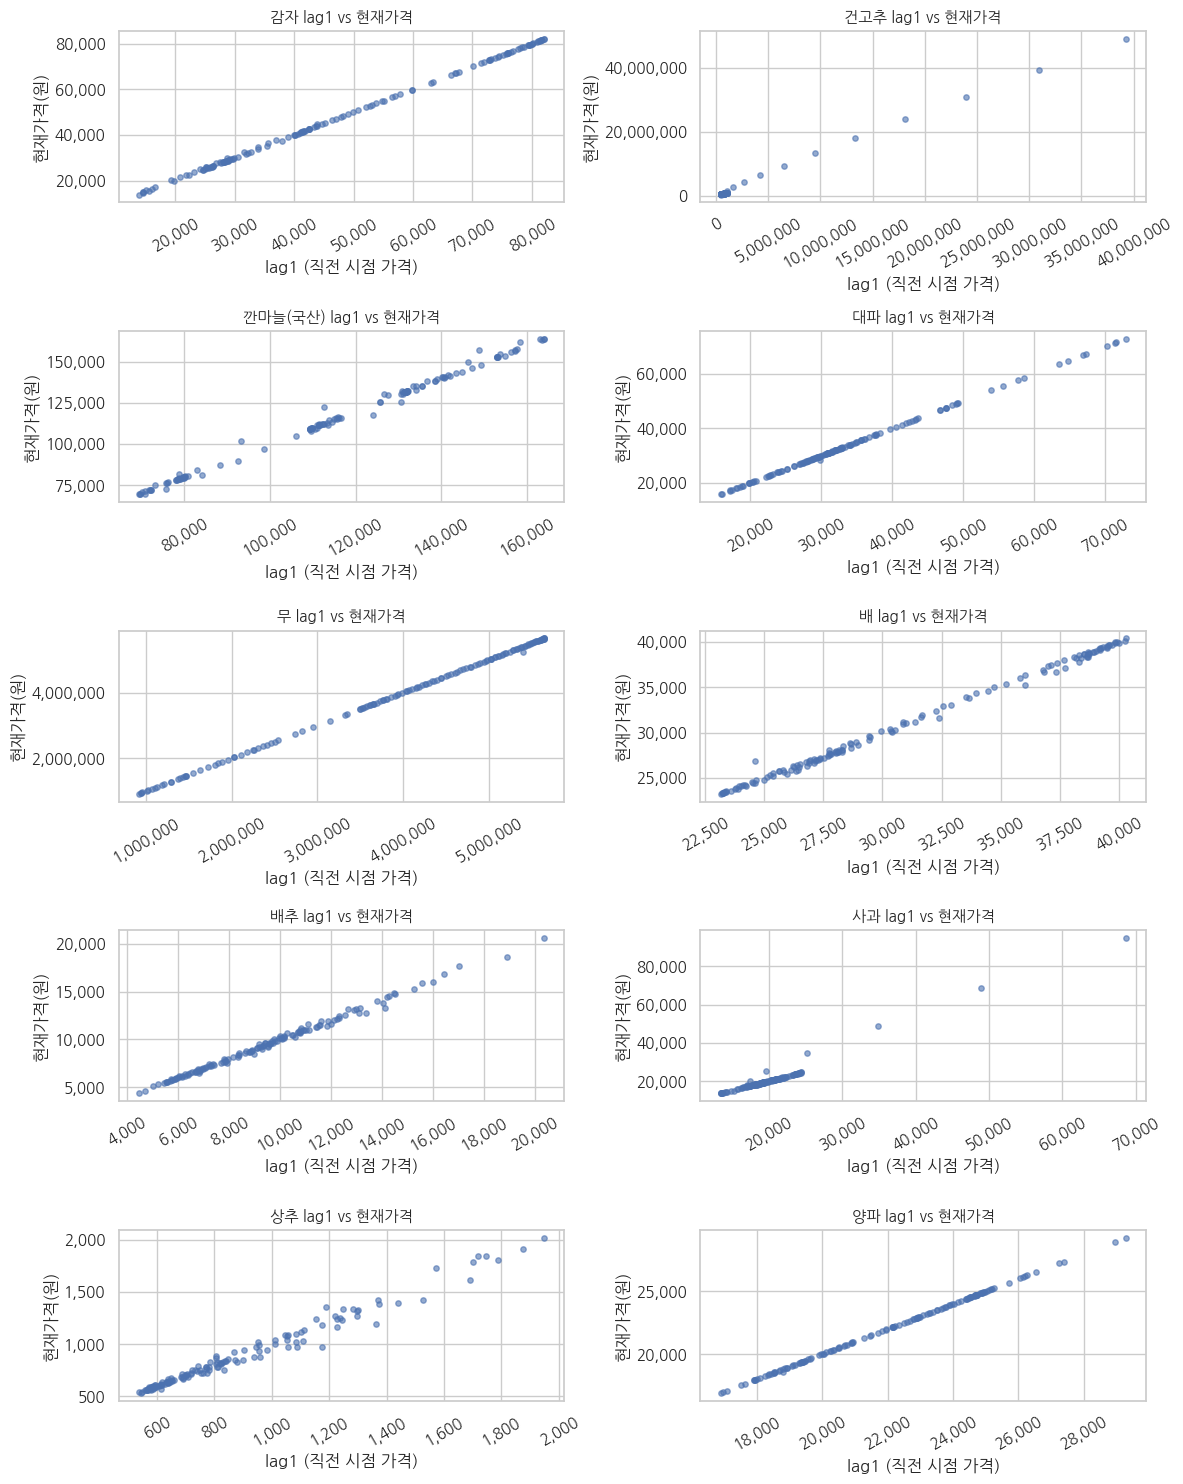

In [39]:
import matplotlib.ticker as ticker

comma_fmt = ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
품목_목록 = sorted(df['품목명'].unique())

# df는 (품목명, t_idx) 기준으로 여러 행이 존재(품종·등급별)
# → 시점당 점 하나가 되도록 평균 집계 후, lag1이 없는 첫 시점 제거
df_lag = (df.groupby(['품목명', 't_idx'], as_index=False)[['평균가격(원)', 'lag1']]
          .mean()
          .dropna(subset=['lag1']))

fig, axes = plt.subplots(5, 2, figsize=(12, 15))
axes = axes.flatten()

for i, 품목 in enumerate(품목_목록):
    item_df = df_lag[df_lag['품목명'] == 품목]
    axes[i].scatter(item_df['lag1'], item_df['평균가격(원)'], s=15, alpha=0.6)
    axes[i].set_title(f'{품목} lag1 vs 현재가격', fontsize=11)
    axes[i].set_xlabel('lag1 (직전 시점 가격)')
    axes[i].set_ylabel('현재가격(원)')
    axes[i].xaxis.set_major_formatter(comma_fmt)
    axes[i].yaxis.set_major_formatter(comma_fmt)
    axes[i].tick_params(axis='x', labelrotation=30)

plt.tight_layout()
plt.show()

### 3-5. 반입량과 현재 가격의 관계

반입량(공급량)과 가격의 관계를 분석한다.  
공급과 가격 사이에는 **시간차**가 있을 수 있으므로 세 가지 시점의 상관계수를 비교한다.

- `corr_0`: 같은 시점 반입량 & 가격 — **동행 상관**
- `corr_vol_lag1`: 이전 시점 반입량 & 현재 가격 — *이전 공급이 다음 가격에 영향을 주는가?*
- `corr_vol_lead1`: 현재 가격 & 다음 시점 반입량 — *가격이 먼저 변하고 공급이 따라 변하는가?*

**관찰 결과**

동행 상관(`corr_0`) 기준으로 **대부분 품목에서 음의 상관관계**가 확인되었다.  
공급이 늘면 가격이 내려가는 일반적인 시장 원리가 농산물에서도 성립한다.

- **상추·양파·감자**: 동행 상관 -0.4 이하 — 공급 변화에 가격이 민감하게 반응
- **배추·깐마늘**: 상관이 거의 0에 가까움 — 반입량 외 다른 요인(품위·수요)이 더 크게 작용
- **건고추**: 메타 데이터가 없어 반입량이 0으로 고정 → 분산 없음, 상관 계산 불가(NaN)

일부 품목에서는 `corr_vol_lag1`이 `corr_0`보다 절댓값이 크게 나타나, **이전 시점 공급이 현재 가격에 더 강하게 영향을 미치는** 경향이 확인된다.

## 4. 모델링

### TFT (Temporal Fusion Transformer)

LSTM과 Attention 구조를 결합한 시계열 예측 딥러닝 모델이다.  
단순 LSTM 대비 강점은 **어떤 시점·변수가 예측에 중요했는지 해석 가능**하다는 점이다.

**예측 태스크**
- 입력: 각 품목의 과거 N순 가격 + 수급·계절성 피처
- 출력: 다음 **+1순, +2순, +3순** 가격 (품목별 독립 예측)

**TFT 내부 피처 역할 구분**

| 역할 | 피처 | 이유 |
|---|---|---|
| `time_varying_known_reals` | `month`, `sin_month`, `cos_month`, `sin_순`, `cos_순`, `is_event` | 미래 날짜도 미리 계산 가능 |
| `time_varying_unknown_reals` | `평균가격`, `total_반입량`, `event_impact` | 예측 시점에 아직 모름 |
| `static_categoricals` | `품목명` | 품목별 임베딩 학습 |

> lag1~lag9, rolling mean은 TFT 입력에서 제외한다.  
> TFT의 attention 메커니즘이 시간 의존성을 자체적으로 학습하므로 중복이며,  
> 오히려 노이즈가 될 수 있다.

In [40]:
import pytorch_forecasting, torch, lightning
print(f"pytorch-forecasting {pytorch_forecasting.__version__}")
print(f"torch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

pytorch-forecasting 1.6.1
torch 2.11.0+cpu | CUDA: False


### 4-1. 학습 데이터 준비

`df`는 (품목명, 시점)에 품종·등급별로 여러 행이 있다.  
TFT는 시점당 하나의 값만 받으므로, `(품목명, t_idx)` 기준으로 평균 집계한다.

lag1~lag9, rolling mean은 TFT 입력에서 제외하고,  
**시간 피처(seasonal) + 수급 피처(반입량, event_impact)** 만 사용한다.

In [41]:
tft_cols = ['품목명', 't_idx', '평균가격(원)',
            'month', '순', 'sin_month', 'cos_month', 'sin_순', 'cos_순',
            'is_event', 'event_impact', 'total_반입량']

# 품종·등급 차이를 제거하고 시점당 하나의 값으로 집계
df_tft = (df[tft_cols]
          .groupby(['품목명', 't_idx'], as_index=False)
          .agg({
              '평균가격(원)':  'mean',
              'total_반입량': 'mean',
              'month':       'first',
              '순':           'first',
              'sin_month':   'first',
              'cos_month':   'first',
              'sin_순':      'first',
              'cos_순':      'first',
              'is_event':    'first',
              'event_impact':'first',
          })
          .sort_values(['품목명', 't_idx'])
          .reset_index(drop=True))

# pytorch-forecasting 요구사항: group_id는 문자열, 가격은 float32
df_tft['품목명'] = df_tft['품목명'].astype(str)

# 스플라인 보간의 극단값(inf/음수)이 집계 후에도 잔존할 수 있으므로 품목별로 ffill/bfill 보완
df_tft['평균가격(원)'] = (df_tft['평균가격(원)']
                         .replace([np.inf, -np.inf], np.nan)
                         .clip(lower=0).replace(0, np.nan))
df_tft['평균가격(원)'] = (df_tft.groupby('품목명')['평균가격(원)']
                         .transform(lambda x: x.ffill().bfill())
                         .astype('float32'))
df_tft['total_반입량'] = df_tft['total_반입량'].fillna(0).astype('float32')

nan_cnt = df_tft['평균가격(원)'].isna().sum()
print(f"shape: {df_tft.shape}  |  평균가격 NaN: {nan_cnt}")
print(f"t_idx 범위: {df_tft['t_idx'].min()} ~ {df_tft['t_idx'].max()}")
print(f"품목 수: {df_tft['품목명'].nunique()}, 품목별 시점 수: {df_tft.groupby('품목명').size().unique()}")

shape: (1440, 12)  |  평균가격 NaN: 0
t_idx 범위: 0 ~ 143
품목 수: 10, 품목별 시점 수: [144]


### 4-2. TimeSeriesDataSet 정의

**Train / Val 분리**  
마지막 12순(1개 계절)을 검증 세트로 사용한다.  
검증 세트는 훈련 세트 끝부분과 encoder 길이만큼 겹쳐서 생성해야 한다.

**encoder / prediction 길이**
- `max_encoder_length = 18`: 과거 6개월(2개 계절) 참조
- `max_prediction_length = 3`: 다음 +1, +2, +3순 예측

In [42]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE

MAX_ENCODER = 18
MAX_PRED    = 3
VAL_CUTOFF  = df_tft['t_idx'].max() - 12   # 마지막 12순을 검증용으로

train_data = df_tft[df_tft['t_idx'] <= VAL_CUTOFF]
# 검증 세트: encoder가 훈련 데이터를 볼 수 있도록 MAX_ENCODER만큼 앞으로 당김
val_data   = df_tft[df_tft['t_idx'] > VAL_CUTOFF - MAX_ENCODER]

training = TimeSeriesDataSet(
    train_data,
    time_idx             = 't_idx',
    target               = '평균가격(원)',
    group_ids            = ['품목명'],
    max_encoder_length   = MAX_ENCODER,
    min_encoder_length   = 9,
    max_prediction_length= MAX_PRED,
    static_categoricals  = ['품목명'],
    time_varying_known_reals = [
        't_idx', 'month', 'sin_month', 'cos_month', 'sin_순', 'cos_순', 'is_event'
    ],
    time_varying_unknown_reals = ['평균가격(원)', 'total_반입량', 'event_impact'],
    target_normalizer    = GroupNormalizer(groups=['품목명'], transformation='softplus'),
    add_relative_time_idx= True,
    add_target_scales    = True,
    add_encoder_length   = True,
)

validation = TimeSeriesDataSet.from_dataset(
    training, val_data, predict=True, stop_randomization=True
)

train_loader = training.to_dataloader(train=True,  batch_size=64, num_workers=0)
val_loader   = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

print(f"훈련 샘플: {len(training)}, 검증 샘플: {len(validation)}")

훈련 샘플: 1300, 검증 샘플: 10


### 4-3. TFT 모델 정의 & 학습

데이터가 4년치(품목당 144순)로 소규모이므로 모델 크기를 작게 유지한다.

| 하이퍼파라미터 | 값 | 의미 |
|---|---|---|
| `hidden_size` | 32 | LSTM/Attention 내부 차원 |
| `attention_head_size` | 4 | Multi-head attention 헤드 수 |
| `dropout` | 0.1 | 과적합 방지 |
| `hidden_continuous_size` | 16 | 연속 변수 임베딩 차원 |
| `max_epochs` | 50 | 조기 종료(EarlyStopping) 포함 |

In [43]:
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate        = 0.03,
    hidden_size          = 32,
    attention_head_size  = 4,
    dropout              = 0.1,
    hidden_continuous_size = 16,
    loss                 = MAE(),
    log_interval         = 10,
    reduce_on_plateau_patience = 4,
)
print(f"파라미터 수: {tft.size() / 1e3:.1f}k")

early_stop = EarlyStopping(monitor='val_loss', patience=7, mode='min')
checkpoint = ModelCheckpoint(monitor='val_loss', save_top_k=1, mode='min', filename='tft-best')

trainer = L.Trainer(
    max_epochs         = 50,
    accelerator        = 'auto',
    gradient_clip_val  = 0.1,
    callbacks          = [early_stop, checkpoint],
    enable_progress_bar= True,
    logger             = False,
)

trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)
print(f"\n최적 val_loss: {early_stop.best_score:.4f}")

파라미터 수: 97.5k


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | MAE                             | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 60     | train | 0    
3  | prescalers                         | ModuleDict                      | 448    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 5.9 K  | train | 0

Epoch 8: 100%|██████████| 20/20 [00:02<00:00,  8.25it/s, train_loss_step=4.67e+4, val_loss=3.91e+6, train_loss_epoch=5.14e+4]

최적 val_loss: 3899279.5000


### 4-4. 테스트 데이터 전처리

각 TEST_XX.csv는 상대적 시점(T-8순 ~ T순)으로 기록되어 있다.  
예측을 위해 이 상대 시점을 학습 데이터의 절대 `t_idx`에 매핑해야 계절성 피처를 정확히 사용할 수 있다.

**매핑 방법**: 모든 품목의 `T`순 평균가격 벡터를 학습 데이터의 각 시점과 비교해 유클리드 거리가 가장 가까운 `t_idx`를 찾는다.

In [44]:
import glob

# 학습 데이터의 t_idx별 품목 평균가격 피벗 (매핑용 참조 테이블)
pivot_train = (df_tft.pivot(index='t_idx', columns='품목명', values='평균가격(원)')
               .fillna(method='ffill').fillna(method='bfill'))

순_map_rev = {1: '상순', 2: '중순', 3: '하순'}

def find_t_idx(test_path):
    """TEST_XX.csv에서 T순의 품목별 평균가격 → 학습 데이터 t_idx 매핑"""
    raw = pd.read_csv(test_path, encoding='utf-8-sig')
    # T순 행만 추출 후 품목별 평균가격 집계
    t_row = (raw[raw['시점'] == 'T']
             .groupby('품목명')['평균가격(원)'].mean())
    # 학습 데이터와 공통 품목만 비교
    common = pivot_train.columns.intersection(t_row.index)
    dist = ((pivot_train[common] - t_row[common].values) ** 2).sum(axis=1)
    return int(dist.idxmin())

def load_test(test_path, t_idx_T):
    """TEST_XX.csv → TFT 입력용 DataFrame (t_idx_T 기준으로 절대 t_idx 부여)"""
    raw = pd.read_csv(test_path, encoding='utf-8-sig')

    # 상대 시점 문자열 → 정수 오프셋
    순_offset = {'T': 0, **{f'T-{i}순': -i for i in range(1, 9)}}
    raw = raw[raw['시점'].isin(순_offset)]
    raw['t_idx'] = raw['시점'].map(순_offset) + t_idx_T

    agg = (raw.groupby(['품목명', 't_idx'], as_index=False)['평균가격(원)'].mean())
    agg['품목명'] = agg['품목명'].astype(str)
    agg['평균가격(원)'] = agg['평균가격(원)'].astype('float32')

    # 학습 데이터에서 seasonal/supply 피처 join
    feat_cols = ['품목명', 't_idx', 'month', '순', 'sin_month', 'cos_month',
                 'sin_순', 'cos_순', 'is_event', 'event_impact', 'total_반입량']
    agg = agg.merge(df_tft[feat_cols], on=['품목명', 't_idx'], how='left')

    # 매핑되지 않는 시점(학습 범위 밖)은 인접 시점에서 ffill
    agg = agg.sort_values(['품목명', 't_idx'])
    for col in ['month', '순', 'sin_month', 'cos_month', 'sin_순', 'cos_순',
                'is_event', 'event_impact', 'total_반입량']:
        agg[col] = agg[col].ffill().bfill()

    agg['total_반입량'] = agg['total_반입량'].fillna(0).astype('float32')
    return agg

# 전체 테스트 파일 처리
test_files = sorted(glob.glob('./Data/test/TEST_*.csv'))
test_records = {}   # {test_id: (t_idx_T, DataFrame)}

for path in test_files:
    tid = path.split('TEST_')[-1].replace('.csv', '')
    t_idx_T = find_t_idx(path)
    test_df  = load_test(path, t_idx_T)
    test_records[tid] = (t_idx_T, test_df)

print(f"처리 완료: {len(test_records)}개 테스트")
print({k: v[0] for k, v in list(test_records.items())[:5]})

처리 완료: 25개 테스트
{'00': 41, '01': 50, '02': 41, '03': 41, '04': 41}


### 4-5. 예측 & 제출 파일 생성

각 테스트에 대해 학습된 TFT로 +1순, +2순, +3순 가격을 예측하고  
`sample_submission.csv` 형식에 맞춰 저장한다.

In [46]:
def make_future_rows(품목_list, t_idx_T):
    """T+1, T+2, T+3 시점의 피처 행 생성 (target=0.0 placeholder)"""
    rows = []
    for step in range(1, MAX_PRED + 1):
        ft = t_idx_T + step
        month_ord = ft % 36
        month = month_ord // 3 + 1
        순_val = month_ord % 3 + 1
        m, s = month, 순_val
        is_ev = int(
            ((m == 1) & (s == 3)) or ((m == 2) & (s in [1, 2])) or
            ((m == 9) & (s in [2, 3])) or ((m == 10) & (s == 1)) or
            (m == 11)
        )
        for 품목 in 품목_list:
            rows.append({
                '품목명':      str(품목),
                't_idx':      ft,
                '평균가격(원)': 0.0,          # placeholder (예측 대상)
                'month':      month,
                '순':          순_val,
                'sin_month':  float(np.sin(2 * np.pi * month / 12)),
                'cos_month':  float(np.cos(2 * np.pi * month / 12)),
                'sin_순':     float(np.sin(2 * np.pi * 순_val / 3)),
                'cos_순':     float(np.cos(2 * np.pi * 순_val / 3)),
                'is_event':   is_ev,
                'event_impact': 0.0,
                'total_반입량': 0.0,
            })
    df = pd.DataFrame(rows)
    df['평균가격(원)'] = df['평균가격(원)'].astype('float32')
    df['total_반입량'] = df['total_반입량'].astype('float32')
    return df

# 최적 체크포인트에서 모델 로드
best_tft = TemporalFusionTransformer.load_from_checkpoint(checkpoint.best_model_path)
best_tft.eval()

submission = pd.read_csv('./sample_submission.csv')
품목_list  = sorted(df_tft['품목명'].unique().tolist())

for tid, (t_idx_T, test_df) in test_records.items():
    future_df = make_future_rows(품목_list, t_idx_T)
    combined  = (pd.concat([df_tft, test_df, future_df], ignore_index=True)
                 .drop_duplicates(subset=['품목명', 't_idx'], keep='last')
                 .sort_values(['품목명', 't_idx'])
                 .reset_index(drop=True))

    for 품목 in 품목_list:
        try:
            item_data = combined[combined['품목명'] == 품목].copy()
            item_ds   = TimeSeriesDataSet.from_dataset(
                training, item_data,
                predict=True, stop_randomization=True,
                min_prediction_idx=t_idx_T + 1,
            )
            item_loader = item_ds.to_dataloader(train=False, batch_size=1, num_workers=0)
            pred = best_tft.predict(item_loader, mode='prediction')   # (1, MAX_PRED)
            pred_vals = pred.numpy().flatten()

        except Exception:
            # 예측 실패 시 마지막 알려진 가격으로 대체
            last_known = test_df[test_df['품목명'] == 품목]['평균가격(원)']
            fallback   = float(last_known.iloc[-1]) if len(last_known) > 0 else 0.0
            pred_vals  = [fallback] * MAX_PRED

        for step in range(MAX_PRED):
            row_key = f'TEST_{tid}+{step+1}순'
            if row_key in submission['시점'].values:
                submission.loc[submission['시점'] == row_key, 품목] = float(pred_vals[step])

submission.to_csv('./submission_spline_tft.csv', index=False)
print("제출 파일 저장: submission_spline_tft.csv")
display(submission.head(6))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

제출 파일 저장: submission_spline_tft.csv


,시점,감자,건고추,깐마늘(국산),대파,무,배추,사과,상추,양파,배
0,TEST_00+1순,72991.007812,894355.3750,140175.437500,45983.144531,5334770.0,12595.568359,22560.439453,1159.780762,25258.742188,37646.226562
1,TEST_00+2순,72768.750000,892457.0625,139916.640625,45862.417969,5319592.0,12564.744141,22532.650391,1156.781250,25231.373047,37586.390625
2,TEST_00+3순,72413.656250,889647.4375,139501.609375,45664.609375,5294867.5,12514.463867,22488.529297,1151.834717,25186.453125,37488.445312
3,TEST_01+1순,72991.007812,894355.3750,140175.437500,45983.144531,5334770.0,12595.568359,22560.439453,1159.780762,25258.742188,37646.226562
4,TEST_01+2순,72768.750000,892457.0625,139916.640625,45862.417969,5319592.0,12564.744141,22532.650391,1156.781250,25231.373047,37586.390625
5,TEST_01+3순,72413.656250,889647.4375,139501.609375,45664.609375,5294867.5,12514.463867,22488.529297,1151.834717,25186.453125,37488.445312


         corr_0  corr_vol_lag1  corr_vol_lead1
품목명                                           
감자       -0.265         -0.319          -0.166
건고추         NaN            NaN             NaN
깐마늘(국산)  -0.069         -0.048          -0.076
대파       -0.276         -0.329          -0.270
무         0.092          0.052           0.081
배        -0.107         -0.096          -0.115
배추        0.021         -0.045           0.102
사과       -0.186         -0.186          -0.179
상추       -0.487         -0.502          -0.431
양파       -0.298         -0.338          -0.235


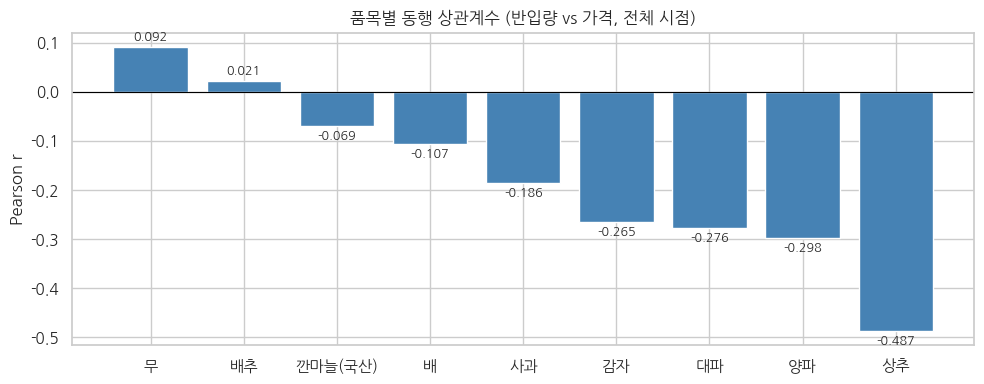

In [ ]:
# 시점당 하나의 값으로 집계 (품종·등급 차이 제거)
df_vol = (df.groupby(['품목명', 't_idx'], as_index=False)[['평균가격(원)', 'total_반입량']]
          .mean())

# 품목별 3가지 시점의 상관계수 계산
# 건고추는 반입량이 0으로 고정 → 분산=0 이므로 corr=NaN, 자동 제외
records = []
for 품목 in sorted(df_vol['품목명'].unique()):
    m = df_vol[df_vol['품목명'] == 품목].sort_values('t_idx').copy()
    records.append({
        '품목명':         품목,
        'corr_0':        m['평균가격(원)'].corr(m['total_반입량']),
        'corr_vol_lag1': m['평균가격(원)'].corr(m['total_반입량'].shift(1)),   # 이전 공급 → 현재 가격
        'corr_vol_lead1':m['평균가격(원)'].corr(m['total_반입량'].shift(-1)),  # 현재 가격 → 다음 공급
    })

corr_df = pd.DataFrame(records).set_index('품목명')
print(corr_df.round(3).to_string())

# 동행 상관계수 시각화 (corr_0 기준, 오름차순 정렬)
corr_sorted = corr_df['corr_0'].dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(corr_sorted.index, corr_sorted.values, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('품목별 동행 상관계수 (반입량 vs 가격, 전체 시점)')
ax.set_ylabel('Pearson r')

plt.tight_layout()
plt.show()